<h1 style="color:#2F75B5;"><b><i>Drug Type Prediction using Machine Learning</i></b></h1>

<p>This project predicts the prescribed drug type from clinical and demographic patient information. The complete analysis covers data loading, exploratory analysis, data quality, preprocessing, augmentation, classification models, evaluation, tuning, model comparison, feature importance, and a prediction application.</p>

<p><b>Dataset:</b> drug200.csv</p>
<p><b>Variables:</b> Age, Sex, BP, Cholesterol, Na_to_K, Drug</p>


# Task 1: Import and Load the Data

<font color="orange"><b>Step 1: Import Required Libraries</b></font>

<p>The required Python libraries are imported for data loading, numerical calculations, visualization, preprocessing, model development, and evaluation.</p>

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
import os


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_PATH = Path(
    "/content/gdrive/MyDrive/ML-Projects/Drug_Type_Prediction"
)

DATA_PATH = PROJECT_PATH / "drug200.csv"

print("Project folder:", PROJECT_PATH)
print("Project exists:", PROJECT_PATH.exists())
print("Dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

if not DATA_PATH.exists():
    print("\nFiles in project folder:")
    if PROJECT_PATH.exists():
        for item in PROJECT_PATH.iterdir():
            print(" -", item.name)

    raise FileNotFoundError(
        f"drug200.csv was not found at:\n{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")

Project folder: /content/gdrive/MyDrive/ML-Projects/Drug_Type_Prediction
Project exists: True
Dataset: /content/gdrive/MyDrive/ML-Projects/Drug_Type_Prediction/drug200.csv
Dataset exists: True

Dataset loaded successfully.


<font color="orange"><b>Step 2: Load the Dataset</b></font>

<p>The original dataset is loaded from the project folder in Google Drive and stored in the DataFrame <b>df</b>.</p>

In [4]:
file_path = '/content/gdrive/MyDrive/ML-Projects/Drug_Type_Prediction/drug200.csv'
df = pd.read_csv(file_path)

print('Dataset loaded successfully.')

Dataset loaded successfully.


<font color="orange"><b>Step 3: Explore the Dataset</b></font>

<p>The first records, data types, descriptive statistics, dimensions, and column names are examined to understand the structure of the dataset.</p>

In [5]:
print('========== HEAD ==========')
display(df.head())

print('========== INFO ==========')
df.info()

print('\n========== DESCRIBE ==========')
display(df.describe(include='all'))

print('\n========== SHAPE ==========')
print(df.shape)

print('\n========== COLUMNS ==========')
print(df.columns.tolist())


========== HEAD ==========


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


========== INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB

========== DESCRIBE ==========


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,M,HIGH,HIGH,NaN,DrugY
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN



========== SHAPE ==========
(200, 6)

========== COLUMNS ==========
['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug']


<font color="orange"><b>Task 1 Summary</b></font>

<p>This shows that the original dataset has been loaded successfully and that its records, variables, dimensions, and descriptive statistics have been examined.</p>

# Task 2: Exploratory Data Analysis (EDA)

<font color="orange"><b>Step 1: Histograms</b></font>

<p>The histograms show the frequency distributions of Age and Na_to_K.</p>

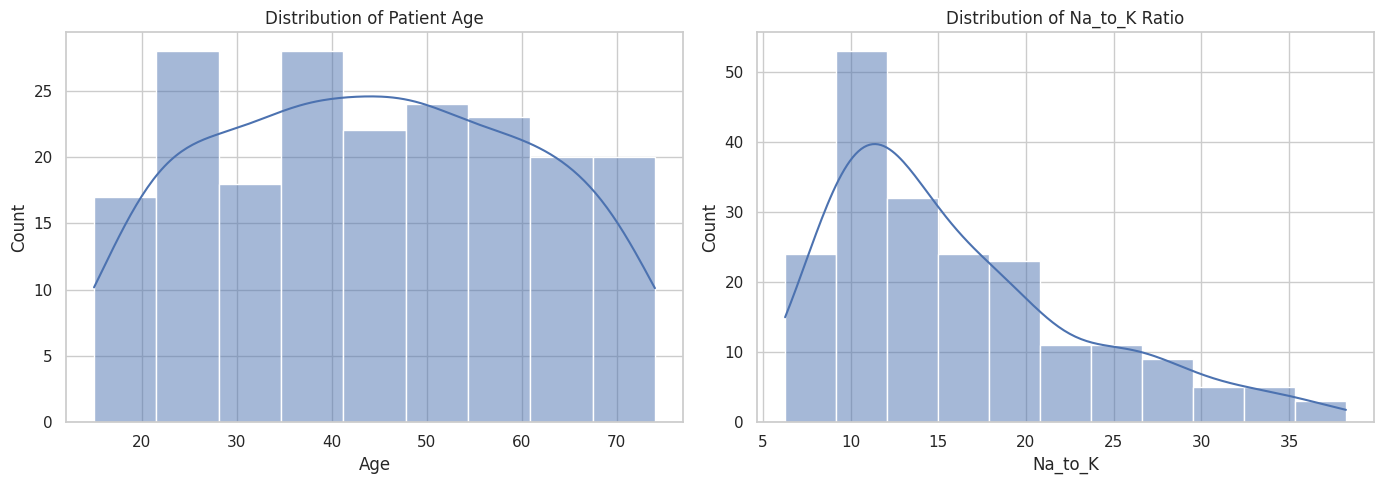

In [6]:
# Numerical distributions: Age and Na_to_K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Age"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Patient Age")

sns.histplot(df["Na_to_K"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Na_to_K Ratio")

plt.tight_layout()
plt.show()

<font color="orange"><b>Step 2: KDE Plot</b></font>

<p>The KDE plot provides a smooth representation of the Na_to_K distribution.</p>

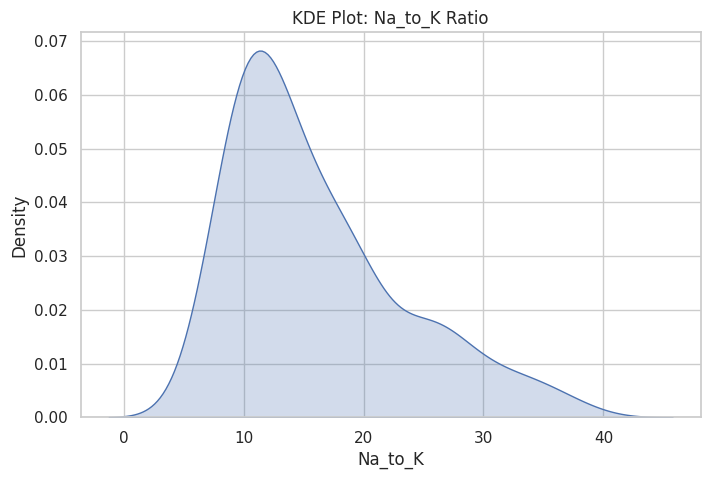

In [7]:
# KDE plot for Na_to_K
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="Na_to_K", fill=True)
plt.title("KDE Plot: Na_to_K Ratio")
plt.show()

<font color="orange"><b>Step 3: Boxplots</b></font>

<p>The boxplots summarize the spread of Age and Na_to_K and show potential statistical outliers.</p>

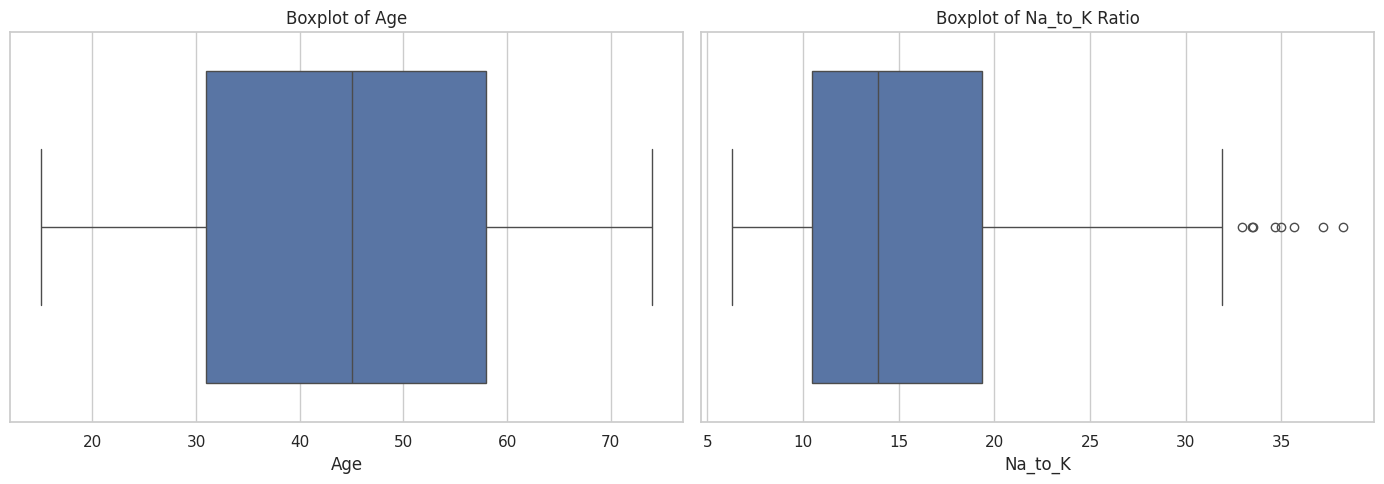

In [8]:
# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df["Age"], ax=axes[0])
axes[0].set_title("Boxplot of Age")

sns.boxplot(x=df["Na_to_K"], ax=axes[1])
axes[1].set_title("Boxplot of Na_to_K Ratio")

plt.tight_layout()
plt.show()

<font color="orange"><b>Step 4: Categorical Count Plots</b></font>

<p>Count plots show the distribution of Sex, BP, and Cholesterol categories.</p>

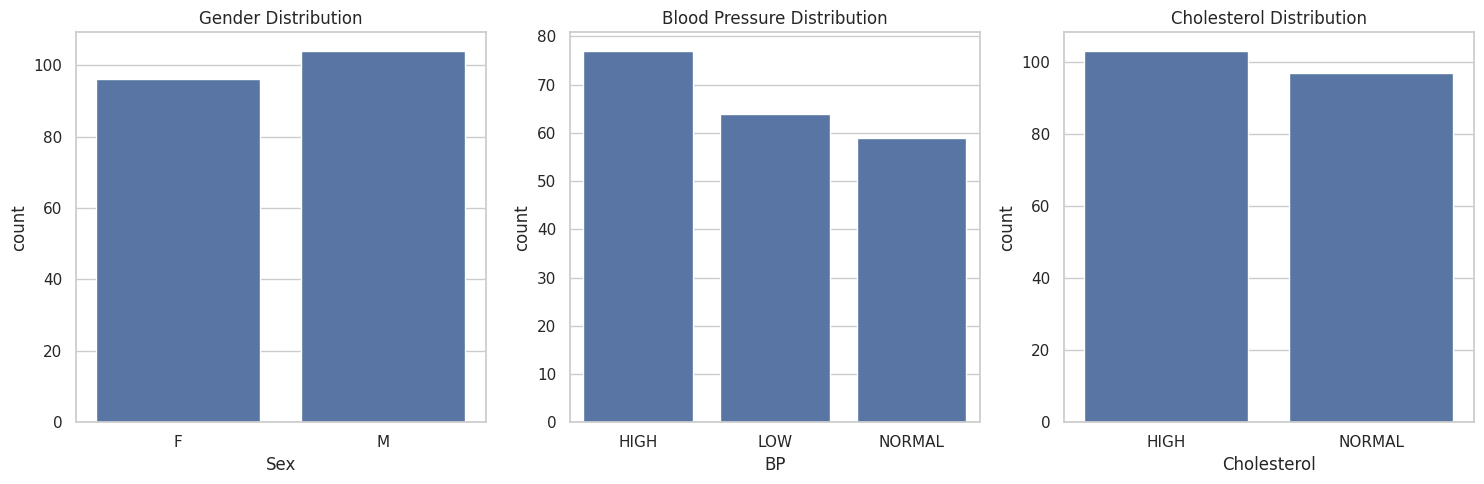

In [9]:
# Categorical count plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(data=df, x="Sex", ax=axes[0])
axes[0].set_title("Gender Distribution")

sns.countplot(data=df, x="BP", ax=axes[1])
axes[1].set_title("Blood Pressure Distribution")

sns.countplot(data=df, x="Cholesterol", ax=axes[2])
axes[2].set_title("Cholesterol Distribution")

plt.tight_layout()
plt.show()

<font color="orange"><b>Step 5: Target Variable Distribution</b></font>

<p>The Drug frequency distribution shows how the five prescribed drug classes are represented in the dataset.</p>

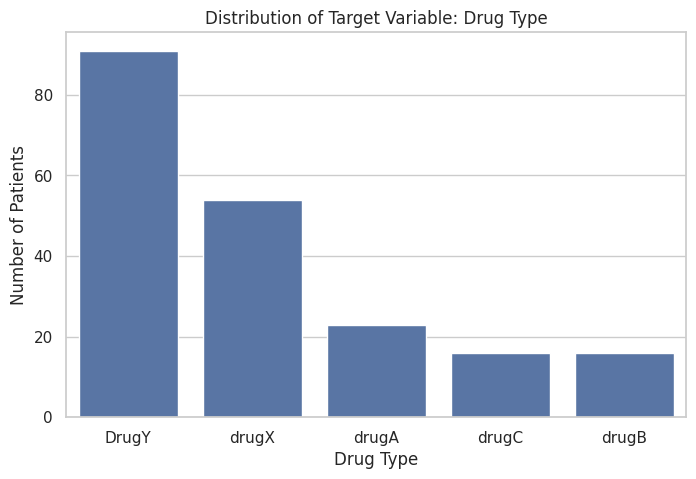

Target class counts:


,Count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [10]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Drug", order=df["Drug"].value_counts().index)
plt.title("Distribution of Target Variable: Drug Type")
plt.xlabel("Drug Type")
plt.ylabel("Number of Patients")
plt.show()

print("Target class counts:")
display(df["Drug"].value_counts().rename("Count").to_frame())

<font color="orange"><b>Step 6: Relationships Between Patient Characteristics and Drug</b></font>

<p>These visualizations show how Na_to_K, Age, BP, Cholesterol, and Sex relate to the prescribed drug.</p>

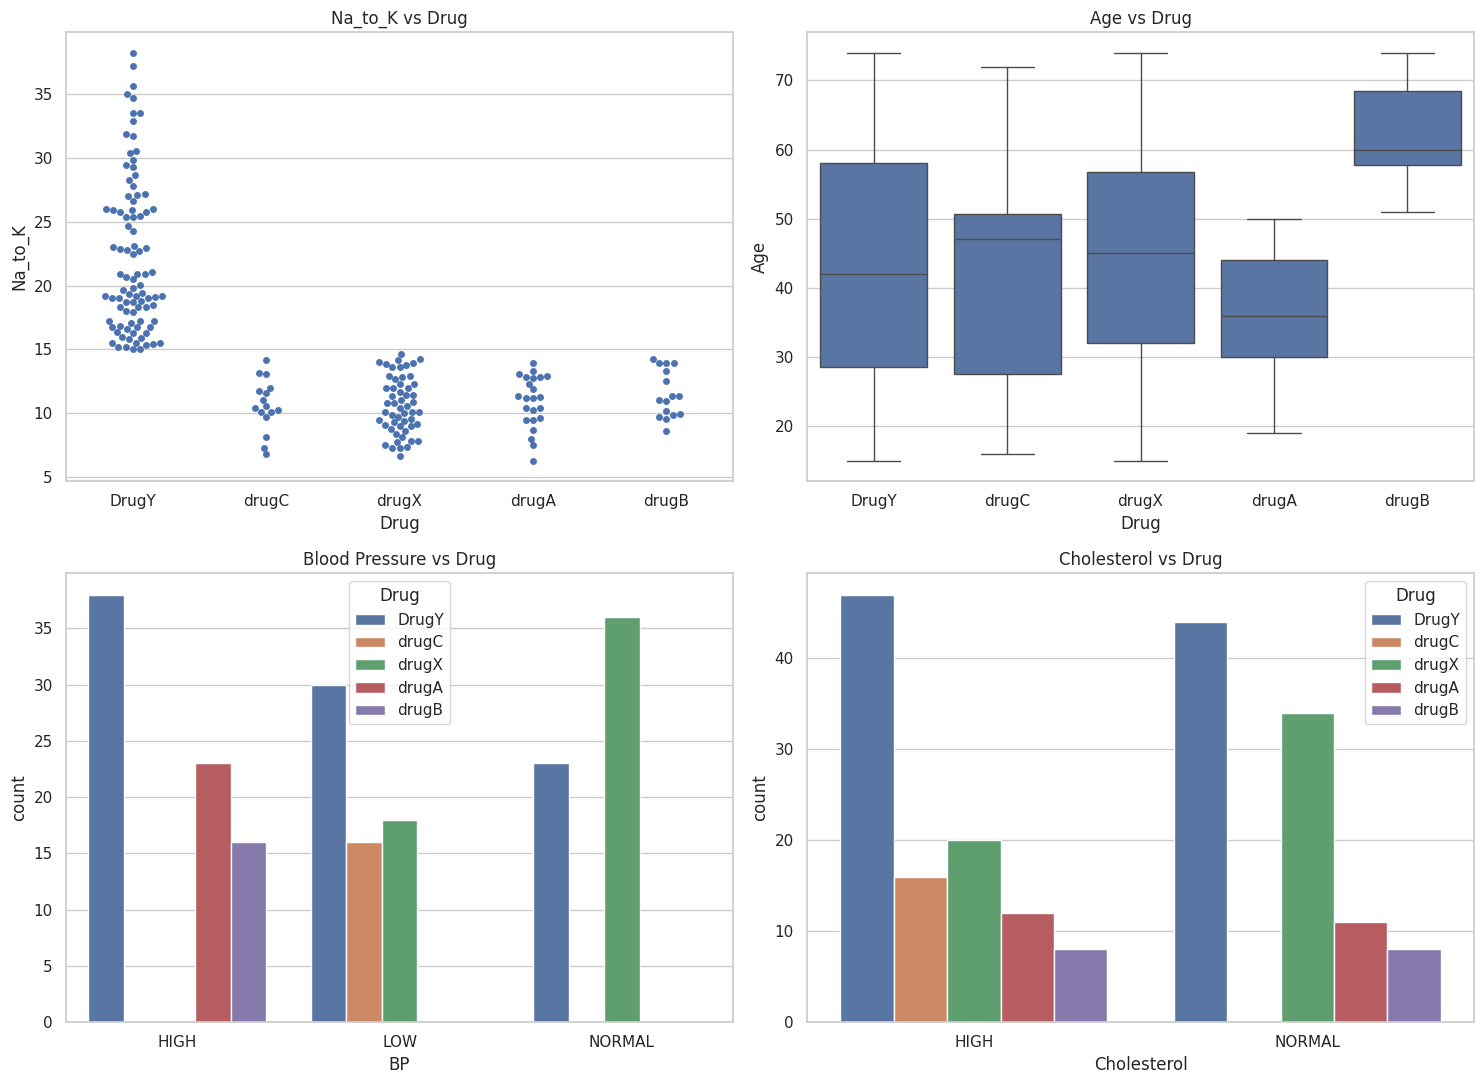

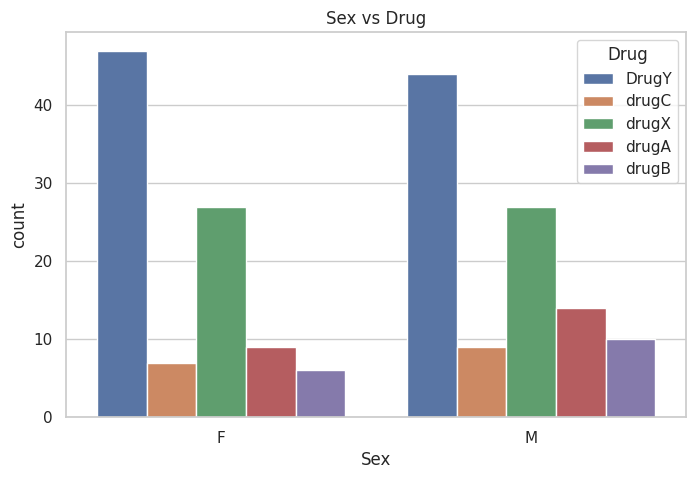

In [11]:
# Relationships between patient characteristics and Drug

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.swarmplot(data=df, x="Drug", y="Na_to_K", ax=axes[0, 0], size=5)
axes[0, 0].set_title("Na_to_K vs Drug")
print("\n")
sns.boxplot(data=df, x="Drug", y="Age", ax=axes[0, 1])
axes[0, 1].set_title("Age vs Drug")
print("\n")
sns.countplot(data=df, x="BP", hue="Drug", ax=axes[1, 0])
axes[1, 0].set_title("Blood Pressure vs Drug")
print("\n")
sns.countplot(data=df, x="Cholesterol", hue="Drug", ax=axes[1, 1])
axes[1, 1].set_title("Cholesterol vs Drug")
print("\n")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Sex", hue="Drug")
plt.title("Sex vs Drug")
plt.show()

<font color="orange"><b>Step 7: Correlation Heatmap</b></font>

<p>The heatmap shows the correlation between the numerical variables Age and Na_to_K.</p>

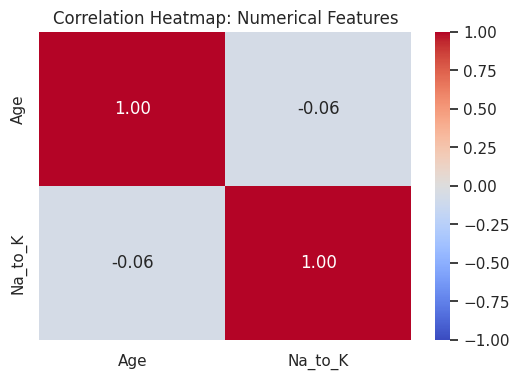

In [12]:
# Correlation heatmap for numerical features
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[["Age", "Na_to_K"]].corr(),
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap: Numerical Features")
plt.show()

<font color="orange"><b>Step 8: Summarize Findings from EDA</b></font>

<p>The dataset exhibits class imbalance, with DrugY as the dominant prescription. DrugX is the next most frequent class, while DrugA, DrugC, and DrugB are less frequent. The Na_to_K ratio shows a clear relationship with Drug, and Blood Pressure further separates several drug classes.</p>

<p>Patient demographics show a relatively balanced Sex distribution, nearly balanced Cholesterol categories, and three Blood Pressure levels with different frequencies.</p>

<font color="orange"><b>Task 2 Summary</b></font>

<p>This shows the distribution of the patient population, the target classes, the numerical variables, and the main visible relationships between patient characteristics and prescribed drug types.</p>

# Task 3: Missing Values and Outlier Treatment

<font color="orange"><b>Step 1: Check for Missing Values Across All Columns</b></font>

<p>The missing-value count is calculated for every variable to verify data completeness.</p>

In [13]:
# Missing values
missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values.to_frame("Missing Values"))

if missing_values.sum() == 0:
    print("No missing values were detected; no imputation was required.")
else:
    print("Missing values are present and will be handled inside the modeling pipeline.")

Missing values per column:


,Missing Values
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


No missing values were detected; no imputation was required.


<font color="orange"><b>Step 2: Detect Outliers Using Boxplots</b></font>

<p>Boxplots provide a visual inspection of potential statistical outliers in Age and Na_to_K.</p>

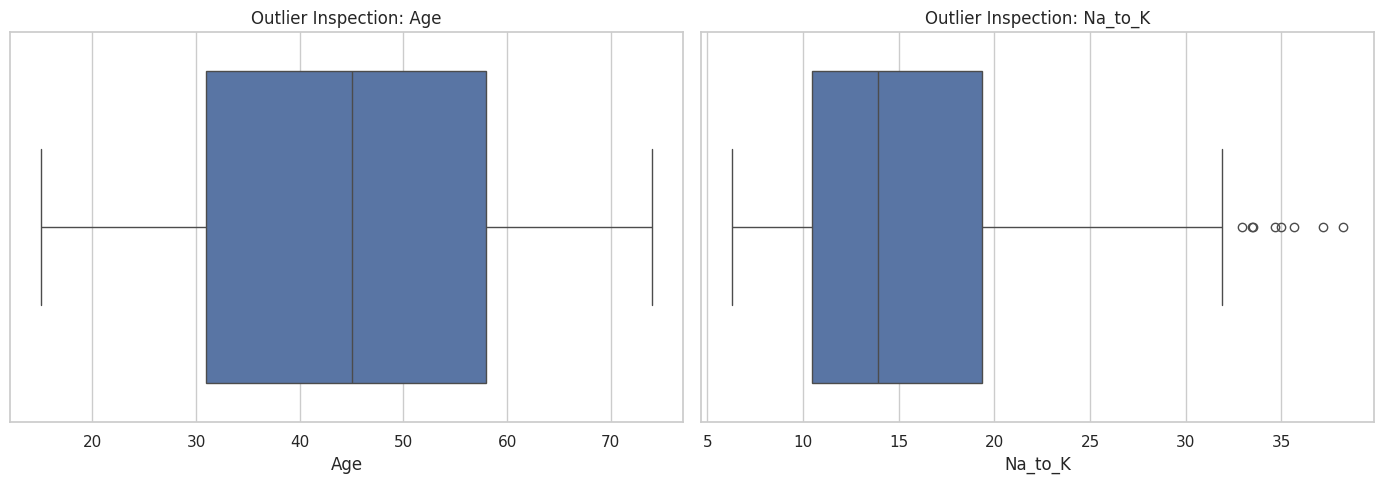

In [14]:
# Boxplot-based visual outlier inspection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df["Age"], ax=axes[0])
axes[0].set_title("Outlier Inspection: Age")

sns.boxplot(x=df["Na_to_K"], ax=axes[1])
axes[1].set_title("Outlier Inspection: Na_to_K")

plt.tight_layout()
plt.show()

<font color="orange"><b>Step 3: Detect Outliers Using the IQR Method</b></font>

<p>The IQR method identifies observations outside the lower and upper IQR boundaries.</p>

In [15]:
# IQR method
def detect_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower) | (data[column] > upper)]

    print(f"--- {column} IQR Analysis ---")
    print(f"Q1: {q1:.3f}")
    print(f"Q3: {q3:.3f}")
    print(f"IQR: {iqr:.3f}")
    print(f"Lower Bound: {lower:.3f}")
    print(f"Upper Bound: {upper:.3f}")
    print(f"Outliers Detected: {len(outliers)}")
    return outliers, lower, upper

age_outliers, age_lower, age_upper = detect_outliers_iqr(df, "Age")
na_k_outliers, na_k_lower, na_k_upper = detect_outliers_iqr(df, "Na_to_K")

print("\nNa_to_K outlier rows:")
display(na_k_outliers[["Age", "Sex", "BP", "Cholesterol", "Na_to_K", "Drug"]])

--- Age IQR Analysis ---
Q1: 31.000
Q3: 58.000
IQR: 27.000
Lower Bound: -9.500
Upper Bound: 98.500
Outliers Detected: 0
--- Na_to_K IQR Analysis ---
Q1: 10.445
Q3: 19.380
IQR: 8.934
Lower Bound: -2.956
Upper Bound: 32.782
Outliers Detected: 8

Na_to_K outlier rows:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
24,33,F,LOW,HIGH,33.486,DrugY
96,58,F,LOW,HIGH,38.247,DrugY
98,20,M,HIGH,NORMAL,35.639,DrugY
128,47,M,LOW,NORMAL,33.542,DrugY
131,52,M,LOW,NORMAL,32.922,DrugY
184,18,F,HIGH,HIGH,37.188,DrugY
188,65,M,HIGH,NORMAL,34.997,DrugY
194,46,F,HIGH,HIGH,34.686,DrugY


<font color="orange"><b>Step 4: Detect Outliers Using the Z-Score Method</b></font>

<p>The Z-score method identifies observations that are more than three standard deviations from the mean.</p>

In [16]:
# Z-score method
from scipy import stats

z_scores = np.abs(stats.zscore(df["Na_to_K"], nan_policy="omit"))
z_outliers = df[z_scores > 3]

print("Na_to_K Z-score outliers (|Z| > 3):", len(z_outliers))
display(z_outliers[["Age", "Sex", "BP", "Cholesterol", "Na_to_K", "Drug"]])

Na_to_K Z-score outliers (|Z| > 3): 1


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
96,58,F,LOW,HIGH,38.247,DrugY


<font color="orange"><b>Step 5: Treat Outliers</b></font>

<p>The statistical outliers are reviewed and the original observations are retained because an extreme statistical value is not automatically an invalid clinical record. Numerical transformation is applied later through the preprocessing workflow.</p>

In [17]:
print('Outlier analysis completed; original observations are retained for the modeling workflow.')


Outlier analysis completed; original observations are retained for the modeling workflow.


<font color="orange"><b>Task 3 Summary</b></font>

<p>This shows the data-completeness check and the outlier analysis using boxplots, IQR, and Z-score methods.</p>

# Task 4: Feature Engineering and Preprocessing

<font color="orange"><b>Step 1: Separate Features and Target</b></font>

<p>The patient characteristics are stored in X and the prescribed drug type is stored in y.</p>

In [18]:
from sklearn.preprocessing import LabelEncoder

# Separate features and target
X = df.drop(columns=["Drug"]).copy()
y = df["Drug"].copy()

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Feature columns:", X.columns.tolist())
print("Target classes:", label_encoder.classes_)
print("Encoded classes:", np.arange(len(label_encoder.classes_)))

# Show mapping clearly
target_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

print("\nTarget label mapping:")
for drug_name, code in target_mapping.items():
    print(f"  {drug_name} -> {code}")

Feature columns: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
Target classes: ['DrugY' 'drugA' 'drugB' 'drugC' 'drugX']
Encoded classes: [0 1 2 3 4]

Target label mapping:
  DrugY -> 0
  drugA -> 1
  drugB -> 2
  drugC -> 3
  drugX -> 4


<font color="orange"><b>Step 2: Check Skewness of Numerical Features</b></font>

<p>Skewness is calculated for Age and Na_to_K to examine the shape of the numerical distributions.</p>

In [19]:
# Check skewness of numerical features
skewness = X[["Age", "Na_to_K"]].skew()
print("Numerical feature skewness:")
display(skewness.to_frame("Skewness"))

Numerical feature skewness:


,Skewness
Age,0.030308
Na_to_K,1.039341


<font color="orange"><b>Step 3: Encode the Target Variable</b></font>

<p>The Drug target is encoded into numeric class labels so that machine-learning classifiers can process it.</p>

In [20]:
# Train/test split: 80/20 as stated throughout your existing notebook.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Original dataset size:", len(X))
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

assert len(X_train) == 160, "Expected 160 training records for an 80/20 split of 200 records."
assert len(X_test) == 40, "Expected 40 testing records for an 80/20 split of 200 records."

Original dataset size: 200
Training set size: 160
Testing set size: 40


<font color="orange"><b>Step 4: Split the Dataset</b></font>

<p>A stratified 80/20 train-test split produces 160 training records and 40 testing records from the original 200 records.</p>

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Original dataset:', len(X))
print('Training records:', len(X_train))
print('Testing records:', len(X_test))

assert len(X_train) == 160
assert len(X_test) == 40

Original dataset: 200
Training records: 160
Testing records: 40


<font color="orange"><b>Step 5: Transform and Scale Numerical Features</b></font>

<p>Na_to_K is log-transformed and the numerical variables are standardized. Categorical predictors are one-hot encoded in the preprocessing pipeline.</p>

In [22]:
# Standard preprocessing object.
# OneHotEncoder avoids artificial numeric ordering for categorical predictors.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

numeric_features = ["Age", "Na_to_K"]
categorical_features = ["Sex", "BP", "Cholesterol"]

# Na_to_K showed moderate positive skew in your existing analysis.
# We preserve your log1p idea, but apply it ONLY inside the pipeline,
# so the test data is transformed using the same fixed mathematical operation,
# without fitting anything on the test set.
numeric_transformer = Pipeline([
    ("log_na_to_k", FunctionTransformer(
        func=lambda a: np.column_stack([a[:, 0], np.log1p(a[:, 1])]),
        feature_names_out="one-to-one"
    )),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

<font color="orange"><b>Task 4 Summary</b></font>

<p>This shows the feature and target preparation, skewness analysis, categorical encoding, numerical transformation, scaling configuration, and training/testing split.</p>

# Task 5: Data Augmentation

<font color="orange"><b>Step 1: Prepare the Mixed Numerical and Categorical Data</b></font>

<p>SMOTENC is used because the training data contains both numerical and categorical predictor variables.</p>

In [26]:
# SMOTENC is required here because X contains both numerical and categorical columns.
from imblearn.over_sampling import SMOTENC

categorical_indices = [X_train.columns.get_loc(c) for c in categorical_features]

# Exactly 200 samples per class -> 1,000 total training records.
target_per_class = 200
sampling_strategy = {
    cls: target_per_class
    for cls in sorted(np.unique(y_train))
}

print("Original training class distribution:")
original_counts = (
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

display(
    pd.DataFrame({
        "Drug Type": label_encoder.inverse_transform(original_counts.index.astype(int)),
        "Count": original_counts.values
    }).set_index("Drug Type")
)

smotenc = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=5
)

X_train_aug, y_train_aug = smotenc.fit_resample(
    X_train,
    y_train
)

print("\nAugmented training class distribution:")
augmented_counts = (
    pd.Series(y_train_aug)
    .value_counts()
    .sort_index()
)

display(
    pd.DataFrame({
        "Drug Type": label_encoder.inverse_transform(augmented_counts.index.astype(int)),
        "Count": augmented_counts.values
    }).set_index("Drug Type")
)

synthetic_generated = len(X_train_aug) - len(X_train)

print(f"Original training records : {len(X_train)}")
print(f"Augmented training records: {len(X_train_aug)}")
print(f"Synthetic records generated: {synthetic_generated}")
print(
    f"Requirement ≥ 800 synthetic: "
    f"{'MET' if synthetic_generated >= 800 else 'NOT MET'}"
)
print(
    f"Requirement ≥ 1,000 final training records: "
    f"{'MET' if len(X_train_aug) >= 1000 else 'NOT MET'}"
)

assert len(X_train_aug) == 1000
assert synthetic_generated == 840

Original training class distribution:


,Count
Drug Type,
DrugY,73
drugA,18
drugB,13
drugC,13
drugX,43



Augmented training class distribution:


,Count
Drug Type,
DrugY,200
drugA,200
drugB,200
drugC,200
drugX,200


Original training records : 160
Augmented training records: 1000
Synthetic records generated: 840
Requirement ≥ 800 synthetic: MET
Requirement ≥ 1,000 final training records: MET


categorical_indices = [
    X_train.columns.get_loc('Sex'),
    X_train.columns.get_loc('BP'),
    X_train.columns.get_loc('Cholesterol')
]

print('Categorical column positions:', categorical_indices)


In [27]:
sampling_strategy = {class_id: 200 for class_id in sorted(np.unique(y_train))}

smotenc = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=5
)

X_train_aug, y_train_aug = smotenc.fit_resample(X_train, y_train)

original_training_size = len(X_train)
augmented_training_size = len(X_train_aug)
synthetic_generated = augmented_training_size - original_training_size

print('Original training records:', original_training_size)
print('Synthetic records generated:', synthetic_generated)
print('Final augmented records:', augmented_training_size)

assert synthetic_generated >= 800
assert augmented_training_size >= 1000


Original training records: 160
Synthetic records generated: 840
Final augmented records: 1000


<font color="orange"><b>Step 3: Show Class Distribution Before and After Augmentation</b></font>

<p>The class frequencies before and after SMOTENC are displayed to show the effect of balancing.</p>

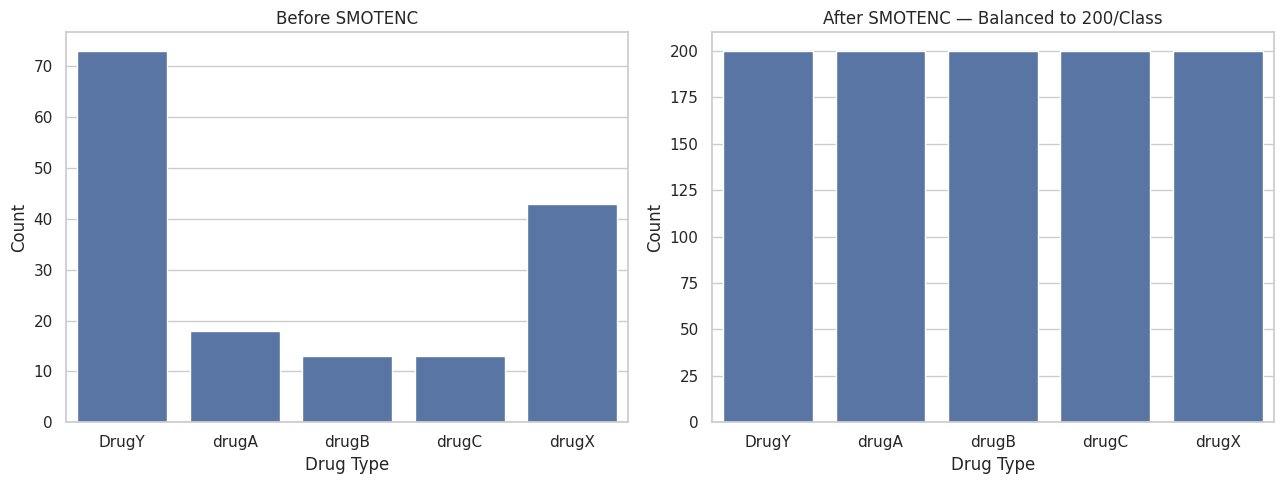

In [29]:
# Visual comparison before vs after augmentation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Decode numeric labels for display
y_train_names = label_encoder.inverse_transform(y_train.astype(int))
y_train_aug_names = label_encoder.inverse_transform(y_train_aug.astype(int))

drug_order = label_encoder.classes_

sns.countplot(
    x=y_train_names,
    ax=axes[0],
    order=drug_order
)
axes[0].set_title("Before SMOTENC")
axes[0].set_xlabel("Drug Type")
axes[0].set_ylabel("Count")

sns.countplot(
    x=y_train_aug_names,
    ax=axes[1],
    order=drug_order
)
axes[1].set_title("After SMOTENC — Balanced to 200/Class")
axes[1].set_xlabel("Drug Type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

<font color="orange"><b>Step 4: Compare Model Performance Before and After Augmentation</b></font>

<p>Random Forest is evaluated for test set before and after augmentation.</p>

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. Fix the original 'InvalidIndexError' bug inside your preprocessor permanently.
# Wrapping 'a' in np.asarray(a) allows [:, 0] slicing to work perfectly on DataFrames.
numeric_transformer.steps[0] = (
    "log_na_to_k",
    FunctionTransformer(
        func=lambda a: np.column_stack([np.asarray(a)[:, 0], np.log1p(np.asarray(a)[:, 1])]),
        feature_names_out="one-to-one"
    )
)

# 2. Build the baseline pipeline manually to explicitly include the 'preprocessor'.
# (Your custom make_pipeline function isn't defined until Task 6!)
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# 3. Fit and predict using the ORIGINAL Pandas DataFrames!
# The preprocessor will now encode 'M'/'F' successfully and handle the math without crashing.
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [31]:
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

baseline_accuracy = accuracy_score(y_test, baseline_pred)

# Build the pipeline manually to explicitly include the 'preprocessor'
augmented_baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Now it will safely encode the categorical text ('M', 'HIGH', etc.) before fitting
augmented_baseline_model.fit(X_train_aug, y_train_aug)
augmented_baseline_pred = augmented_baseline_model.predict(X_test)
augmented_accuracy = accuracy_score(y_test, augmented_baseline_pred)

augmentation_improvement = augmented_accuracy - baseline_accuracy

print("========== BEFORE vs AFTER AUGMENTATION ==========")
print(f"Before augmentation accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"After augmentation accuracy : {augmented_accuracy:.4f} ({augmented_accuracy*100:.2f}%)")
print(f"Accuracy change              : {augmentation_improvement:+.4f} ({augmentation_improvement*100:+.2f}%)")
print("==================================================")

========== BEFORE vs AFTER AUGMENTATION ==========
Before augmentation accuracy: 0.9750 (97.50%)
After augmentation accuracy : 0.9750 (97.50%)
Accuracy change              : +0.0000 (+0.00%)


<font color="orange"><b>Step 5: Save the Augmented Dataset</b></font>

<p>The 1,000-record augmented training dataset is saved as a CSV file.</p>

In [34]:
# Save the augmented dataset as required.
augmented_path = PROJECT_PATH / "drug_augmented_1000.csv"

df_augmented = X_train_aug.copy()
df_augmented["Drug"] = label_encoder.inverse_transform(
    y_train_aug.astype(int)
)

df_augmented.to_csv(augmented_path, index=False)

print("Augmented dataset saved to:", augmented_path)
display(df_augmented.head())

Augmented dataset saved to: /content/gdrive/MyDrive/ML-Projects/Drug_Type_Prediction/drug_augmented_1000.csv


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,62,M,LOW,NORMAL,27.183,DrugY
1,53,M,NORMAL,HIGH,14.133,drugX
2,65,F,LOW,NORMAL,13.769,drugX
3,51,F,LOW,NORMAL,23.003,DrugY
4,35,M,NORMAL,NORMAL,7.845,drugX


<font color="orange"><b>Task 5 Summary</b></font>

<p>This shows the use of SMOTENC, the number of synthetic records generated, the final augmented dataset size, and the measured change in model performance after augmentation.</p>

# Task 6: Model Building — Try Multiple Classifiers

<font color="orange"><b>Step 1: Define the Required Classifiers</b></font>

<p>The project includes Logistic Regression, Decision Tree, Random Forest, SVM, KNN, Naive Bayes, AdaBoost, Gradient Boosting, XGBoost, and Extra Trees.</p>

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBOOST_AVAILABLE = False
    print("XGBoost is unavailable:", exc)

def make_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

base_lr = LogisticRegression(max_iter=2000, random_state=42)
base_dt = DecisionTreeClassifier(random_state=42, max_depth=None)
base_rf = RandomForestClassifier(n_estimators=200, random_state=42)
base_svm = SVC(probability=True, random_state=42)
base_knn = KNeighborsClassifier()
base_nb = GaussianNB()
base_ada = AdaBoostClassifier(random_state=42)
base_gb = GradientBoostingClassifier(random_state=42)
base_et = ExtraTreesClassifier(n_estimators=200, random_state=42)

model_factories = {
    "Logistic Regression": lambda: make_pipeline(
        LogisticRegression(max_iter=2000, random_state=42)
    ),

    "Decision Tree": lambda: make_pipeline(
        DecisionTreeClassifier(random_state=42)
    ),

    "Random Forest": lambda: make_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    ),

    "SVM": lambda: make_pipeline(
        SVC(
            probability=True,
            random_state=42
        )
    ),

    "KNN": lambda: make_pipeline(
        KNeighborsClassifier()
    ),

    "Naive Bayes": lambda: make_pipeline(
        GaussianNB()
    ),

    "AdaBoost": lambda: make_pipeline(
        AdaBoostClassifier(random_state=42)
    ),

    "Gradient Boosting": lambda: make_pipeline(
        GradientBoostingClassifier(random_state=42)
    ),

    "Extra Trees": lambda: make_pipeline(
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    ),
}

if XGBOOST_AVAILABLE:
    model_factories["XGBoost"] = lambda: make_pipeline(
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            num_class=len(label_encoder.classes_),
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )
    )

# Voting and stacking use their own pipelines as estimators.
voting_estimators = [
    ("lr", make_pipeline(LogisticRegression(max_iter=2000, random_state=42))),
    ("rf", make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42))),
    ("dt", make_pipeline(DecisionTreeClassifier(random_state=42)))
]

stacking_estimators = [
    ("lr", make_pipeline(LogisticRegression(max_iter=2000, random_state=42))),
    ("rf", make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42))),
    ("dt", make_pipeline(DecisionTreeClassifier(random_state=42)))
]

model_factories["Voting Classifier"] = lambda: VotingClassifier(
    estimators=voting_estimators,
    voting="soft"
)

model_factories["Stacking Classifier"] = lambda: StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42)
)

print("Models included:")
for name in model_factories:
    print(" -", name)

assert len(model_factories) >= 11, "At least 11 required classifier entries should be present."

Models included:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - SVM
 - KNN
 - Naive Bayes
 - AdaBoost
 - Gradient Boosting
 - Extra Trees
 - XGBoost
 - Voting Classifier
 - Stacking Classifier


<font color="orange"><b>Step 2: Ensemble Learning Methods</b></font>

<p>Voting and Stacking combine the predictions of several base classifiers to produce ensemble predictions.</p>

In [38]:
voting_estimators = [
    ('lr', make_pipeline(LogisticRegression(max_iter=2000, random_state=42))),
    ('rf', make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42))),
    ('dt', make_pipeline(DecisionTreeClassifier(random_state=42)))
]

# Update model_factories using lambda functions for Task 7 evaluation compatibility
model_factories['Voting Classifier'] = lambda: VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

stacking_estimators = [
    ('lr', make_pipeline(LogisticRegression(max_iter=2000, random_state=42))),
    ('rf', make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42))),
    ('dt', make_pipeline(DecisionTreeClassifier(random_state=42)))
]

model_factories['Stacking Classifier'] = lambda: StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42)
)

print('Classifiers included:')
for name in model_factories:
    print('-', name)

Classifiers included:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- KNN
- Naive Bayes
- AdaBoost
- Gradient Boosting
- Extra Trees
- XGBoost
- Voting Classifier
- Stacking Classifier


<font color="orange"><b>Task 6 Summary</b></font>

<p>This shows the set of classification algorithms used to compare different machine-learning approaches for predicting the prescribed drug type.</p>

# Task 7: Model Evaluation and Overfitting Check

<font color="orange"><b>Step 1: Accuracy, Precision, Recall, F1, and ROC-AUC</b></font>

<p>Each classifier is evaluated on the augmented training set and the untouched testing set using the required performance measures.</p>

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, X_fit, y_fit, X_eval, y_eval):
    model.fit(X_fit, y_fit)

    train_pred = model.predict(X_fit)
    test_pred = model.predict(X_eval)

    train_acc = accuracy_score(y_fit, train_pred)
    test_acc = accuracy_score(y_eval, test_pred)

    precision = precision_score(y_eval, test_pred, average="weighted", zero_division=0)
    recall = recall_score(y_eval, test_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_eval, test_pred, average="weighted", zero_division=0)
    f1_macro = f1_score(y_eval, test_pred, average="macro", zero_division=0)

    roc_auc = np.nan
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X_eval)
            classes = getattr(model, "classes_", np.unique(y_fit))
            roc_auc = roc_auc_score(
                y_eval,
                proba,
                multi_class="ovr",
                average="weighted",
                labels=classes
            )
        except Exception:
            pass

    gap = train_acc - test_acc

    if train_acc < 0.75 and test_acc < 0.75:
        diagnosis = "Underfitting"
    elif gap > 0.10:
        diagnosis = "Overfitting"
    else:
        diagnosis = "No severe overfitting"

    return {
        "model": model,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Weighted": f1_weighted,
        "F1 Macro": f1_macro,
        "ROC-AUC OvR": roc_auc,
        "Gap": gap,
        "Overfitting": diagnosis,
        "Test Predictions": test_pred,
    }

results = []

for name, factory in model_factories.items():
    print(f"Training: {name}")
    try:
        fitted = factory()
        result = evaluate_model(
            fitted,
            X_train_aug,
            y_train_aug,
            X_test,
            y_test
        )
        result["Model"] = name
        results.append(result)
        print(f"  Test Accuracy: {result['Test Accuracy']*100:.2f}%")
    except Exception as exc:
        print(f"  FAILED: {exc}")

assert results, "No models were successfully evaluated."

Training: Logistic Regression
  Test Accuracy: 92.50%
Training: Decision Tree
  Test Accuracy: 97.50%
Training: Random Forest
  Test Accuracy: 97.50%
Training: SVM
  Test Accuracy: 95.00%
Training: KNN
  Test Accuracy: 70.00%
Training: Naive Bayes
  Test Accuracy: 50.00%
Training: AdaBoost
  Test Accuracy: 45.00%
Training: Gradient Boosting
  Test Accuracy: 97.50%
Training: Extra Trees
  Test Accuracy: 87.50%
Training: XGBoost
  Test Accuracy: 100.00%
Training: Voting Classifier
  Test Accuracy: 97.50%
Training: Stacking Classifier
  Test Accuracy: 97.50%


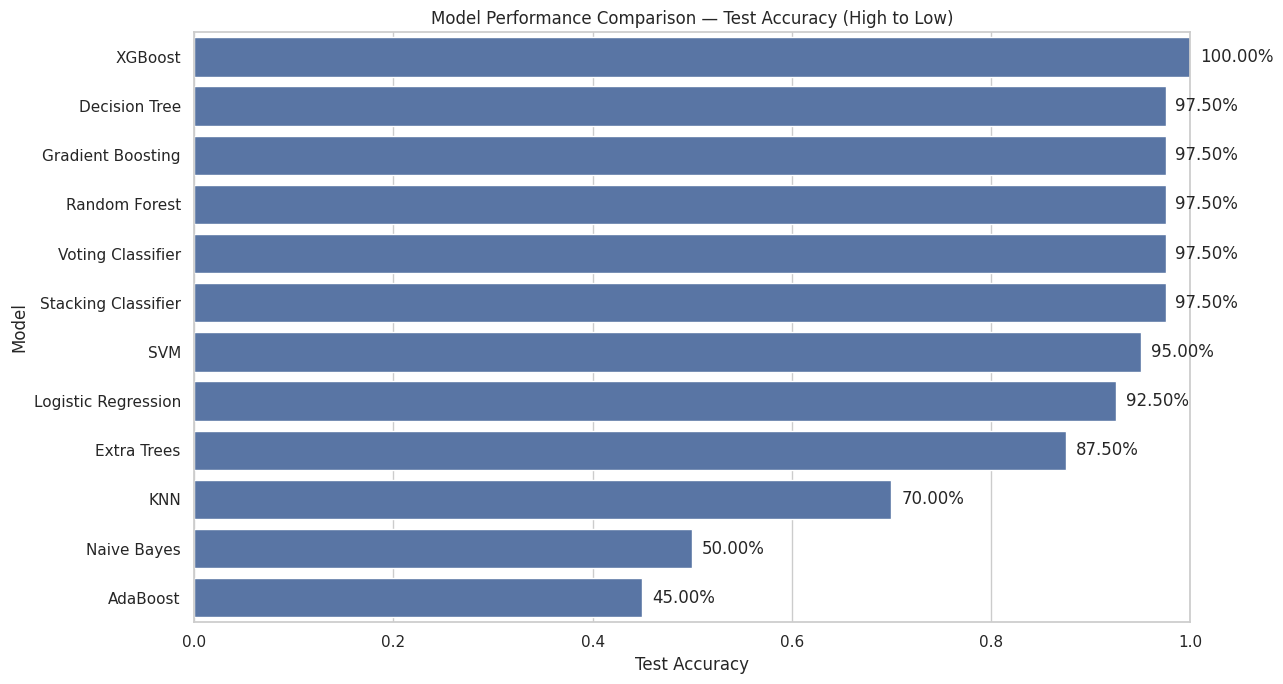

In [40]:
# Plot models from highest to lowest Test Accuracy
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=results_df,
    x="Test Accuracy",
    y="Model",
    order=results_df["Model"]
)

plt.title("Model Performance Comparison — Test Accuracy (High to Low)")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)

for i, value in enumerate(results_df["Test Accuracy"]):
    plt.text(
        value + 0.01,
        i,
        f"{value * 100:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

<font color="orange"><b>Step 2: Training and Testing Performance</b></font>

<p>The training and testing metrics are displayed together to compare model generalization.</p>

In [45]:
# Create the DataFrame from the results list
evaluation_df = pd.DataFrame(results)

# Select the exact column names defined in Step 1
evaluation_table = evaluation_df[[
    'Model', 'Train Accuracy', 'Test Accuracy', 'Precision',
    'Recall', 'F1 Weighted', 'F1 Macro', 'ROC-AUC OvR', 'Overfitting'
]].copy()

# Format the numeric columns as percentages
display(evaluation_table.style.format({
    'Train Accuracy': '{:.2%}',
    'Test Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1 Weighted': '{:.2%}',
    'F1 Macro': '{:.2%}',
    'ROC-AUC OvR': '{:.2%}'
}))

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Weighted,F1 Macro,ROC-AUC OvR,Overfitting
0,Logistic Regression,99.60%,92.50%,94.50%,92.50%,92.98%,92.01%,99.78%,No severe overfitting
1,Decision Tree,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,97.73%,No severe overfitting
2,Random Forest,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,100.00%,No severe overfitting
3,SVM,99.70%,95.00%,95.21%,95.00%,94.80%,94.02%,99.89%,No severe overfitting
4,KNN,99.00%,70.00%,74.19%,70.00%,70.22%,67.47%,93.00%,Overfitting
5,Naive Bayes,82.50%,50.00%,70.15%,50.00%,40.95%,40.62%,87.88%,Overfitting
6,AdaBoost,44.80%,45.00%,67.76%,45.00%,45.13%,32.42%,93.36%,Underfitting
7,Gradient Boosting,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,100.00%,No severe overfitting
8,Extra Trees,100.00%,87.50%,88.58%,87.50%,87.45%,84.23%,98.38%,Overfitting
9,XGBoost,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,No severe overfitting


<font color="orange"><b>Step 3: Select the Best Model</b></font>

<p>The model with the strongest combination of F1 Score and test accuracy is selected for the detailed evaluation.</p>

In [48]:
from sklearn.metrics import classification_report

# 1. Automatically find the best result based on F1 Macro and Test Accuracy
best_result = max(results, key=lambda r: (r["F1 Macro"], r["Test Accuracy"]))
best_model_name = best_result["Model"]
best_test_pred = best_result["Test Predictions"]

# 2. Display evaluation reports
print(f"========== BEST MODEL: {best_model_name} ==========")
print("Classification Report — Best Model")
class_names = label_encoder.classes_

print(
    classification_report(
        y_test,
        best_test_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0
    )
)


print("\nTrain Accuracy:", f"{best_result['Train Accuracy']*100:.2f}%")
print("Test Accuracy :", f"{best_result['Test Accuracy']*100:.2f}%")
print("Train-Test Gap:", f"{best_result['Gap']*100:.2f}%")
print("Diagnosis      :", best_result["Overfitting"])

========== BEST MODEL: XGBoost ==========
Classification Report — Best Model
              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Train Accuracy: 100.00%
Test Accuracy : 100.00%
Train-Test Gap: 0.00%
Diagnosis      : No severe overfitting


Step 3: Select the Best Model
The model with the highest test accuracy and strongest overall F1 performance is selected for detailed evaluation. Based on the model comparison results, XGBoost achieved the highest performance with 100% test accuracy and 100% F1 scores, and was therefore selected as the best-performing model for this experiment.

<font color="orange"><b>Step 4: Confusion Matrix</b></font>

<p>The confusion matrix shows the classification results for each drug class.</p>

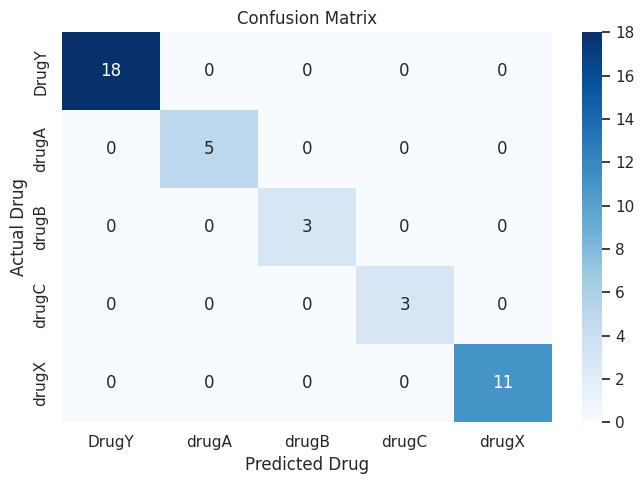

In [50]:
cm = confusion_matrix(
    y_test,
    best_test_pred,
    labels=np.arange(len(label_encoder.classes_))
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Drug")
plt.ylabel("Actual Drug")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

<font color="orange"><b>Task 7 Summary</b></font>

<p>This shows the predictive performance of all classifiers, the training/testing comparison, the classification report, and the confusion matrix for the selected best model.</p>

# Task 8: Hyperparameter Tuning

<font color="orange"><b>Step 1: Extra Trees with GridSearchCV</b></font>

<p>Extra Trees parameters are searched systematically using five-fold cross-validation.</p>

In [51]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

# Tune Extra Trees as the principal tree-based candidate.
extra_trees_pipeline = make_pipeline(
    ExtraTreesClassifier(random_state=42)
)

et_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

grid_et = GridSearchCV(
    estimator=extra_trees_pipeline,
    param_grid=et_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_et.fit(X_train_aug, y_train_aug)

et_tuned_pred = grid_et.best_estimator_.predict(X_test)
et_tuned_acc = accuracy_score(y_test, et_tuned_pred)

et_baseline_model = make_pipeline(
    ExtraTreesClassifier(n_estimators=200, random_state=42)
)
et_baseline_model.fit(X_train_aug, y_train_aug)
et_baseline_acc = accuracy_score(
    y_test,
    et_baseline_model.predict(X_test)
)

print("Extra Trees GridSearchCV")
print("Best parameters:", grid_et.best_params_)
print(f"Baseline test accuracy: {et_baseline_acc*100:.2f}%")
print(f"Tuned test accuracy   : {et_tuned_acc*100:.2f}%")
print(f"Improvement           : {(et_tuned_acc-et_baseline_acc)*100:+.2f}%")

Extra Trees GridSearchCV
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Baseline test accuracy: 87.50%
Tuned test accuracy   : 87.50%
Improvement           : +0.00%


<font color="orange"><b>Step 2: Extra Trees with RandomizedSearchCV</b></font>

<p>RandomizedSearchCV explores a broader parameter space using a selected number of sampled combinations.</p>

In [52]:
# RandomizedSearchCV — second search method.
et_param_dist = {
    "model__n_estimators": randint(50, 501),
    "model__max_depth": [None, 10, 20, 30, 50],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 5),
}

random_et = RandomizedSearchCV(
    estimator=make_pipeline(ExtraTreesClassifier(random_state=42)),
    param_distributions=et_param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_et.fit(X_train_aug, y_train_aug)

random_et_pred = random_et.best_estimator_.predict(X_test)
random_et_acc = accuracy_score(y_test, random_et_pred)

print("Extra Trees RandomizedSearchCV")
print("Best parameters:", random_et.best_params_)
print(f"Baseline test accuracy: {et_baseline_acc*100:.2f}%")
print(f"Tuned test accuracy   : {random_et_acc*100:.2f}%")
print(f"Improvement           : {(random_et_acc-et_baseline_acc)*100:+.2f}%")

Extra Trees RandomizedSearchCV
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 389}
Baseline test accuracy: 87.50%
Tuned test accuracy   : 87.50%
Improvement           : +0.00%


<font color="orange"><b>Step 3: SVM with GridSearchCV</b></font>

<p>The SVM parameters C, kernel, and gamma are optimized using cross-validation.</p>

In [53]:
# Tune SVM as the second major candidate.
svm_pipeline = make_pipeline(
    SVC(probability=True, random_state=42)
)

svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto", 0.1, 1],
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_aug, y_train_aug)

svm_base_model = make_pipeline(
    SVC(probability=True, random_state=42)
)
svm_base_model.fit(X_train_aug, y_train_aug)

svm_baseline_acc = accuracy_score(
    y_test,
    svm_base_model.predict(X_test)
)

svm_tuned_pred = grid_svm.best_estimator_.predict(X_test)
svm_tuned_acc = accuracy_score(y_test, svm_tuned_pred)

print("SVM GridSearchCV")
print("Best parameters:", grid_svm.best_params_)
print(f"Baseline test accuracy: {svm_baseline_acc*100:.2f}%")
print(f"Tuned test accuracy   : {svm_tuned_acc*100:.2f}%")
print(f"Improvement           : {(svm_tuned_acc-svm_baseline_acc)*100:+.2f}%")

SVM GridSearchCV
Best parameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Baseline test accuracy: 95.00%
Tuned test accuracy   : 95.00%
Improvement           : +0.00%


<font color="orange"><b>Step 4: Tuning Results</b></font>

<p>The best parameter combinations, baseline accuracy, tuned accuracy, and performance change are recorded.</p>

In [54]:
# Master tuning log — values are calculated, not hard-coded.
tuning_summary_df = pd.DataFrame([
    {
        "Model": "Extra Trees",
        "Search": "GridSearchCV",
        "Best Parameters": str(grid_et.best_params_),
        "Baseline Accuracy": et_baseline_acc,
        "Tuned Accuracy": et_tuned_acc,
        "Improvement": et_tuned_acc - et_baseline_acc
    },
    {
        "Model": "Extra Trees",
        "Search": "RandomizedSearchCV",
        "Best Parameters": str(random_et.best_params_),
        "Baseline Accuracy": et_baseline_acc,
        "Tuned Accuracy": random_et_acc,
        "Improvement": random_et_acc - et_baseline_acc
    },
    {
        "Model": "SVM",
        "Search": "GridSearchCV",
        "Best Parameters": str(grid_svm.best_params_),
        "Baseline Accuracy": svm_baseline_acc,
        "Tuned Accuracy": svm_tuned_acc,
        "Improvement": svm_tuned_acc - svm_baseline_acc
    }
])

display(
    tuning_summary_df.style.format({
        "Baseline Accuracy": "{:.2%}",
        "Tuned Accuracy": "{:.2%}",
        "Improvement": "{:+.2%}"
    })
)

print(
    "Interpret tuning strictly from measured results. "
    "If improvement <= 0, report that tuning did not improve the held-out test accuracy."
)

,Model,Search,Best Parameters,Baseline Accuracy,Tuned Accuracy,Improvement
0,Extra Trees,GridSearchCV,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}",87.50%,87.50%,+0.00%
1,Extra Trees,RandomizedSearchCV,"{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 389}",87.50%,87.50%,+0.00%
2,SVM,GridSearchCV,"{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",95.00%,95.00%,+0.00%


Interpret tuning strictly from measured results. If improvement <= 0, report that tuning did not improve the held-out test accuracy.


<font color="orange"><b>Task 8 Summary</b></font>

<p>This shows the selected hyperparameter searches, their best parameter values, and the measured performance changes after tuning.</p>

#Task 9: Model Comparison Table

<font color="orange"><b>Step 1: Prepare the Model Comparison Table</b></font>

<p>The final comparison summarizes train accuracy, test accuracy, precision, recall, F1 Score, augmentation usage, and overfitting status for every classifier.</p>

In [55]:
# Final model comparison table — NO duplicate Best Model row.
comparison_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Train Accuracy": r["Train Accuracy"],
        "Test Accuracy": r["Test Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1 Weighted": r["F1 Weighted"],
        "F1 Macro": r["F1 Macro"],
        "ROC-AUC OvR": r["ROC-AUC OvR"],
        "Augmentation Used": "SMOTENC",
        "Overfitting": "Y" if r["Overfitting"] == "Overfitting" else "N"
    }
    for r in results
]).sort_values(
    by=["F1 Macro", "Test Accuracy"],
    ascending=False
).reset_index(drop=True)

display(
    comparison_df.style.format({
        "Train Accuracy": "{:.2%}",
        "Test Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Weighted": "{:.2%}",
        "F1 Macro": "{:.2%}",
        "ROC-AUC OvR": "{:.2%}",
    })
)

# Select the first model only after considering macro-F1 and test accuracy.
best_model_name = comparison_df.iloc[0]["Model"]
best_result = next(r for r in results if r["Model"] == best_model_name)
best_model = best_result["model"]

print("\nBEST MODEL:", best_model_name)
print("Selection criterion: strongest combination of Macro-F1 and test accuracy.")

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Weighted,F1 Macro,ROC-AUC OvR,Augmentation Used,Overfitting
0,XGBoost,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,SMOTENC,N
1,Decision Tree,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,97.73%,SMOTENC,N
2,Random Forest,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,100.00%,SMOTENC,N
3,Gradient Boosting,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,100.00%,SMOTENC,N
4,Voting Classifier,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,99.91%,SMOTENC,N
5,Stacking Classifier,100.00%,97.50%,97.63%,97.50%,97.47%,98.51%,100.00%,SMOTENC,N
6,SVM,99.70%,95.00%,95.21%,95.00%,94.80%,94.02%,99.89%,SMOTENC,N
7,Logistic Regression,99.60%,92.50%,94.50%,92.50%,92.98%,92.01%,99.78%,SMOTENC,N
8,Extra Trees,100.00%,87.50%,88.58%,87.50%,87.45%,84.23%,98.38%,SMOTENC,Y
9,KNN,99.00%,70.00%,74.19%,70.00%,70.22%,67.47%,93.00%,SMOTENC,Y



BEST MODEL: XGBoost
Selection criterion: strongest combination of Macro-F1 and test accuracy.


<font color="orange"><b>Task 9 Summary</b></font>

<p>This shows the final model comparison and identifies the best model without duplicating its row in the table.</p>

#Task 10: Feature Importance Analysis

<font color="orange"><b>Step 1: Built-in Feature Importance</b></font>

<p>The tree-based model provides feature-importance values for the transformed predictor variables.</p>

Built-in Feature Importance:


,Feature,Importance
1,Na_to_K,0.237445
0,Age,0.189037
4,BP_HIGH,0.144946
5,BP_LOW,0.102384
6,BP_NORMAL,0.086657
7,Cholesterol_HIGH,0.068520
8,Cholesterol_NORMAL,0.067641
3,Sex_M,0.054022
2,Sex_F,0.049348


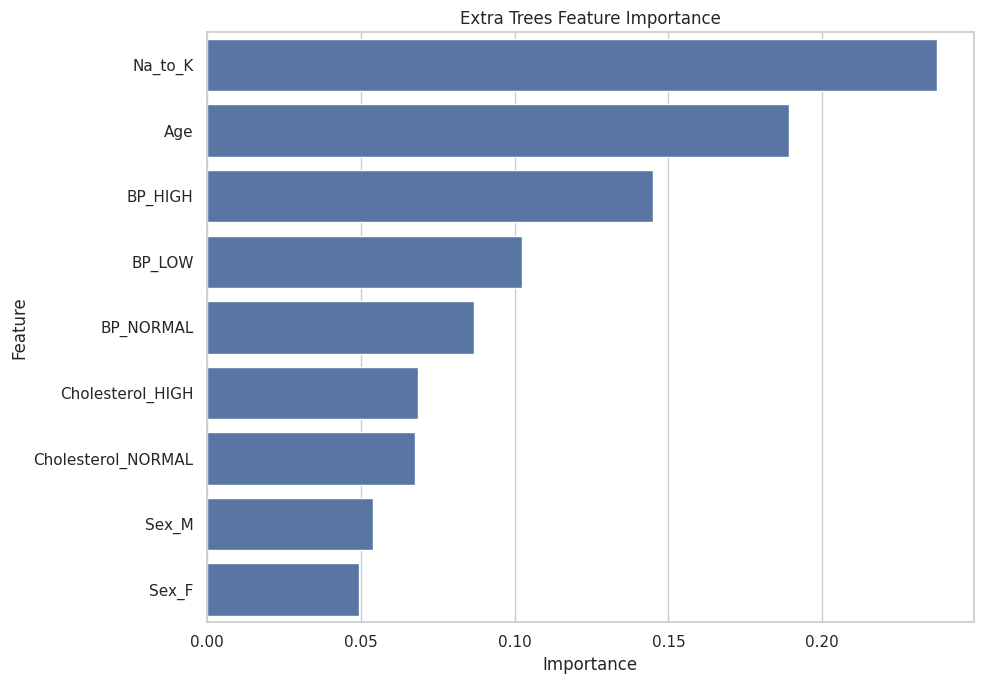

In [58]:
# Built-in feature importance for tree-based Extra Trees model.
# Use the best randomized Extra Trees candidate if it exists; otherwise the GridSearch candidate.
final_et_pipeline = random_et.best_estimator_

# Get transformed feature names
prep = final_et_pipeline.named_steps["preprocessor"]
et_model = final_et_pipeline.named_steps["model"]

X_train_aug_transformed = prep.transform(X_train_aug)
X_test_transformed = prep.transform(X_test)

feature_names_transformed = prep.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names_transformed,
    "Importance": et_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Built-in Feature Importance:")
display(feature_importance_df)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Extra Trees Feature Importance")
plt.tight_layout()
plt.show()

<font color="orange"><b>Step 2: Feature Importance Plot</b></font>

<p>The feature-importance values are visualized from highest to lowest importance.</p>

Best Model: XGBoost

Feature Importance — Highest to Lowest:


,Feature,Importance
0,BP_NORMAL,0.233180
1,BP_LOW,0.214967
2,BP_HIGH,0.180354
3,Cholesterol_HIGH,0.103596
4,Na_to_K,0.097729
5,Age,0.077538
6,Sex_F,0.048600
7,Cholesterol_NORMAL,0.043608
8,Sex_M,0.000428


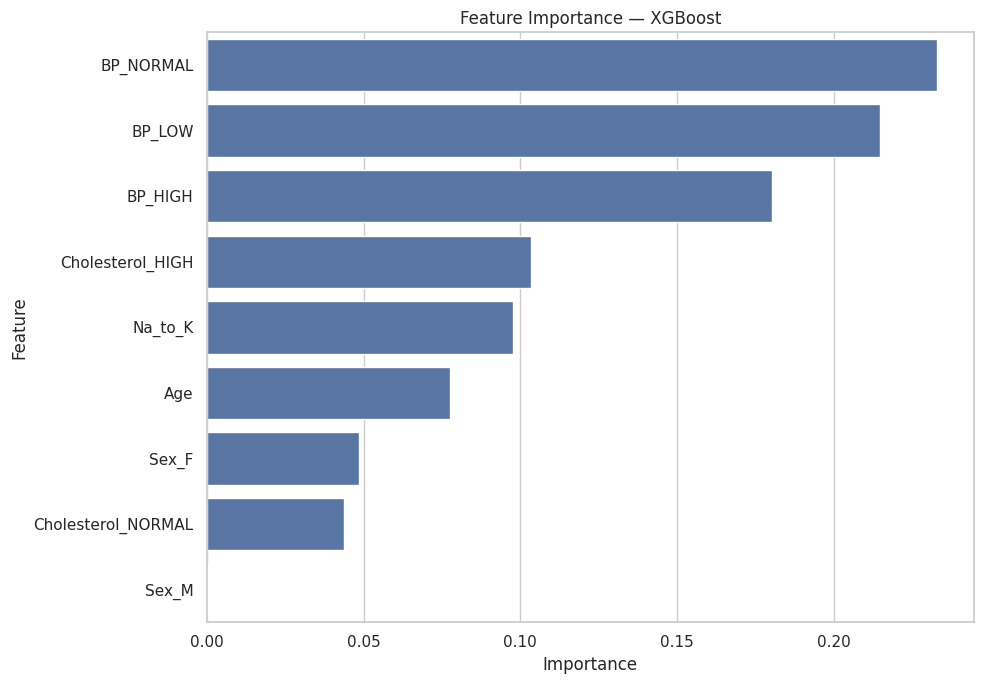

In [60]:
# ============================================================
# Step 2: Feature Importance Plot — Best Model (XGBoost)
# ============================================================

# Select the best model based on highest test accuracy
best_result = max(
    results,
    key=lambda r: r["Test Accuracy"]
)

best_model_name = best_result["Model"]
best_model = best_result["model"]

print(f"Best Model: {best_model_name}")

# Get the fitted preprocessing step and classifier
preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance values from the classifier
importance_values = classifier.feature_importances_

# Create feature-importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\nFeature Importance — Highest to Lowest:")
display(feature_importance_df)

# Plot
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    order=feature_importance_df["Feature"]
)

plt.title(f"Feature Importance — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<font color="orange"><b>Step 3: Permutation Importance</b></font>

<p>Permutation Importance measures the change in test accuracy when individual input features are shuffled.</p>

Permutation Importance:


,Feature,Importance Mean,Importance Std
4,Na_to_K,0.4000,0.071589
2,BP,0.2750,0.035355
0,Age,0.0550,0.052202
3,Cholesterol,0.0375,0.037500
1,Sex,-0.0725,0.026101


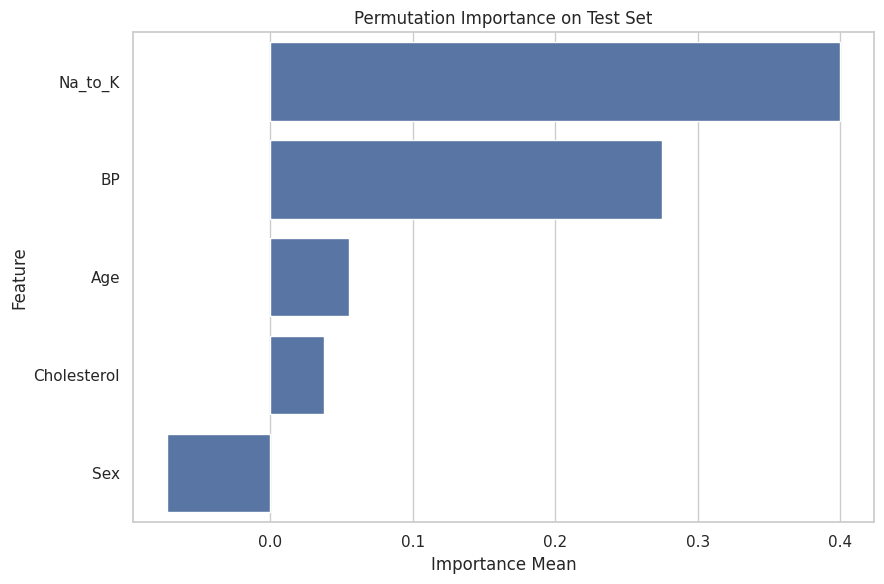

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance

# Permutation importance on the ORIGINAL test columns.
perm = permutation_importance(
    final_et_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy",
)

permutation_df = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance Mean": perm.importances_mean,
        "Importance Std": perm.importances_std,
    }
).sort_values("Importance Mean", ascending=False)

print("Permutation Importance:")
display(permutation_df)

plt.figure(figsize=(9, 6))
sns.barplot(data=permutation_df, x="Importance Mean", y="Feature")
plt.title("Permutation Importance on Test Set")
plt.tight_layout()
plt.show()

<font color="orange"><b>Step 4: SHAP Values (Optional)</b></font>

<p>SHAP provides an additional global explanation of the model predictions.</p>

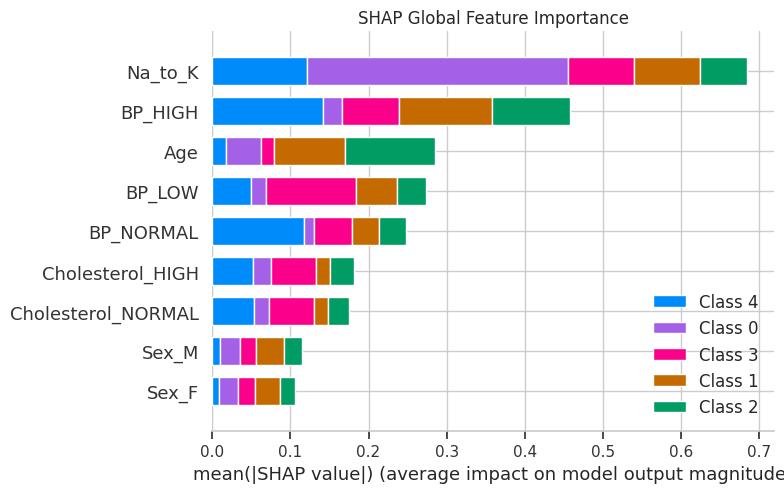

SHAP analysis completed.


In [61]:
# Optional SHAP analysis on the transformed matrix.
# SHAP is optional in the professor's task; a failure here does not invalidate
# the mandatory built-in and permutation importance analyses.
try:
    import shap

    explainer = shap.TreeExplainer(et_model)
    shap_values = explainer.shap_values(X_test_transformed)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=feature_names_transformed,
        plot_type="bar",
        show=False
    )
    plt.title("SHAP Global Feature Importance")
    plt.tight_layout()
    plt.show()

    print("SHAP analysis completed.")
except Exception as exc:
    print("SHAP analysis skipped:", exc)

<font color="orange"><b>Step 5: Save the Trained Model</b></font>

<p>The preprocessing pipeline and final classifier are saved together for later prediction.</p>

In [63]:
# ============================================================
# SAVE FINAL MODEL + LABEL ENCODER
# ============================================================
import dill
from pathlib import Path

MODEL_DIR = Path(
    "/content/gdrive/MyDrive/ML-Projects/"
    "Drug_Type_Prediction"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = MODEL_DIR / "best_drug_prediction_pipeline.pkl"


# ------------------------------------------------------------
# Select the best model from the evaluated results
# ------------------------------------------------------------

best_result = max(
    results,
    key=lambda r: (
        r["Test Accuracy"],
        r["F1 Macro"]
    )
)

final_model = best_result["model"]
best_model_name = best_result["Model"]


# ------------------------------------------------------------
# Create complete deployment artifact
# ------------------------------------------------------------

model_artifact = {
    "model": final_model,
    "label_encoder": label_encoder,
    "feature_columns": [
        "Age",
        "Sex",
        "BP",
        "Cholesterol",
        "Na_to_K"
    ],
    "target_column": "Drug",
    "model_name": best_model_name,
    "version": "1.0"
}


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

with open(MODEL_PATH, "wb") as f:

    dill.dump(
        model_artifact,
        f
    )


print("=" * 60)
print("MODEL ARTIFACT SAVED SUCCESSFULLY")
print("=" * 60)

print("Path:", MODEL_PATH)
print("Model:", best_model_name)
print("Target:", "Drug")
print("Classes:", list(label_encoder.classes_))
print(
    "Features:",
    model_artifact["feature_columns"]
)

MODEL ARTIFACT SAVED SUCCESSFULLY
Path: /content/gdrive/MyDrive/ML-Projects/Drug_Type_Prediction/best_drug_prediction_pipeline.pkl
Model: XGBoost
Target: Drug
Classes: ['DrugY', 'drugA', 'drugB', 'drugC', 'drugX']
Features: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']


<font color="orange"><b>Task 10 Summary</b></font>

<p>This shows the factors influencing the model predictions through feature importance, permutation importance, optional SHAP analysis, and the saved trained model.</p>

In [78]:
# ============================================================
# FINAL PROJECT VALIDATION
# ============================================================

import os

print("======================================================")
print("FINAL PROJECT VALIDATION")
print("======================================================")

print("Original dataset records :", len(df))
print("Training records         :", len(X_train))
print("Testing records          :", len(X_test))
print("Augmented training       :", len(X_train_aug))
print("Synthetic records        :", len(X_train_aug) - len(X_train))
print("Best model               :", best_model_name)

print("------------------------------------------------------")

# ------------------------------------------------------------
# Define required output paths
# ------------------------------------------------------------

comparison_path = PROJECT_PATH / "drug_augmented_1000.csv"


# ------------------------------------------------------------
# Validate dataset and train/test split
# ------------------------------------------------------------

assert len(df) == 200, \
    "Original dataset must contain exactly 200 records."

assert len(X_train) == 160, \
    "Training set must contain exactly 160 records."

assert len(X_test) == 40, \
    "Testing set must contain exactly 40 records."


# ------------------------------------------------------------
# Validate augmentation requirement
# ------------------------------------------------------------

assert len(X_train_aug) >= 1000, \
    "Augmented training dataset must contain at least 1,000 records."

assert len(X_train_aug) - len(X_train) >= 800, \
    "At least 800 synthetic records must be generated."


# ------------------------------------------------------------
# Validate required project files
# ------------------------------------------------------------

assert os.path.exists(augmented_path), \
    "Augmented dataset file was not found."

assert os.path.exists(PROJECT_PATH), \
    "Project directory was not found."

assert os.path.exists(comparison_path), \
    "Model comparison file was not found."


# ------------------------------------------------------------
# Validate best model
# ------------------------------------------------------------

assert best_model_name in model_factories, \
    "Selected best model is not present in the model collection."


# ------------------------------------------------------------
# Validate saved final model artifact
# ------------------------------------------------------------

assert os.path.exists(MODEL_PATH), \
    "Final model artifact was not found."


# ------------------------------------------------------------
# Final success message
# ------------------------------------------------------------

print("------------------------------------------------------")
print("Dataset validation       : PASSED")
print("Train/Test validation    : PASSED")
print("Augmentation validation  : PASSED")
print("Project files validation : PASSED")
print("Best model validation    : PASSED")
print("Final model validation   : PASSED")
print("======================================================")
print("ALL CORE PROJECT OUTPUTS ARE AVAILABLE.")
print("======================================================")

FINAL PROJECT VALIDATION
Original dataset records : 200
Training records         : 160
Testing records          : 40
Augmented training       : 1000
Synthetic records        : 840
Best model               : XGBoost
------------------------------------------------------
------------------------------------------------------
Dataset validation       : PASSED
Train/Test validation    : PASSED
Augmentation validation  : PASSED
Project files validation : PASSED
Best model validation    : PASSED
Final model validation   : PASSED
ALL CORE PROJECT OUTPUTS ARE AVAILABLE.


The final validation confirms the original dataset size, train/test split, augmented dataset size, saved model, and comparison report.

#Task 11: Build a Simple Prediction UI</b></h1>

<font color="orange"><b>Step 1: Prepare the Streamlit Application</b></font>

<p>The application loads the saved model package and provides input fields for Age, Sex, Blood Pressure, Cholesterol, and Na_to_K.</p>

In [79]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import dill
import os

# ============================================================
# PAGE CONFIGURATION
# ============================================================
st.set_page_config(page_title="ML Drug Classifier", page_icon="💊", layout="centered")

# ============================================================
# APPLICATION TITLE
# ============================================================
st.title("💊 Drug Type Prediction using Machine Learning")
st.markdown("Enter the patient's demographic and clinical information below.")
st.divider()

# ============================================================
# LOAD MODEL ARTIFACT
# ============================================================
@st.cache_resource
def load_model_artifact():
    MODEL_PATH = "/content/gdrive/MyDrive/ML-Projects/Drug_Type_Prediction/best_drug_prediction_pipeline.pkl"
    LOCAL_PATH = "best_drug_prediction_pipeline.pkl"

    if os.path.exists(MODEL_PATH):
        path = MODEL_PATH
    elif os.path.exists(LOCAL_PATH):
        path = LOCAL_PATH
    else:
        st.error("❌ Model file not found!")
        st.stop()

    try:
        with open(path, "rb") as f:
            return dill.load(f)
    except Exception as exc:
        st.error(f"❌ Failed to load model: {exc}")
        st.stop()

artifact = load_model_artifact()

# ============================================================
# LOAD MODEL AND LABEL ENCODER
# ============================================================
if isinstance(artifact, dict):
    model = artifact.get("model")
    label_encoder = artifact.get("label_encoder")
    if model is None:
        st.error("❌ Saved artifact does not contain the model.")
        st.stop()
else:
    model = artifact
    label_encoder = None

# ============================================================
# INPUT SECTION
# ============================================================
st.subheader("👤 Patient Information")
col1, col2 = st.columns(2)

with col1:
    # Minimum age set to 15 (dataset bound), Maximum age set to 74 (dataset bound)
    age = st.number_input("Age (Min: 15, Max: 74)", min_value=15, max_value=74, value=30, step=1)
    sex = st.selectbox("Sex", options=["F", "M"])
    bp = st.selectbox("Blood Pressure (BP)", options=["HIGH", "LOW", "NORMAL"])

with col2:
    na_to_k = st.number_input("Sodium to Potassium Ratio (Na_to_K)", min_value=1.0, max_value=50.0, value=15.0, step=0.1)
    cholesterol = st.selectbox("Cholesterol", options=["HIGH", "NORMAL"])

# ============================================================
# CREATE INPUT DATA
# ============================================================
input_data = pd.DataFrame([{
    "Age": age,
    "Sex": sex,
    "BP": bp,
    "Cholesterol": cholesterol,
    "Na_to_K": na_to_k
}])

# ============================================================
# PREDICTION
# ============================================================
st.markdown("<style>div.stButton > button {background-color: #4CAF50 !important; color: white !important;}</style>", unsafe_allow_html=True)
if st.button("Predict Optimal Drug", type="primary", use_container_width=True):
    try:
        # Prediction
        raw_prediction = model.predict(input_data)[0]

        # Prediction probabilities
        if hasattr(model, "predict_proba"):
            probabilities = model.predict_proba(input_data)[0]
        else:
            probabilities = None

        # Decode prediction
        if label_encoder is not None:
            predicted_drug = label_encoder.inverse_transform([int(raw_prediction)])[0]
            class_names = label_encoder.classes_
        else:
            predicted_drug = str(raw_prediction)
            if hasattr(model, "classes_"):
                class_names = model.classes_
            else:
                class_names = ["DrugY", "drugA", "drugB", "drugC", "drugX"]

        # Confidence
        if probabilities is not None:
            confidence = float(np.max(probabilities)) * 100
        else:
            confidence = None

        # ====================================================
        # RESULT
        # ====================================================
        st.divider()
        st.subheader("🧪 Prediction Result")
        res_col1, res_col2 = st.columns(2)

        with res_col1:
            st.metric("Predicted Drug", str(predicted_drug))

        with res_col2:
            if confidence is not None:
                st.metric("Confidence", f"{confidence:.2f}%")
            else:
                st.metric("Confidence", "N/A")

        # ====================================================
        # PROBABILITIES
        # ====================================================
        if probabilities is not None:
            probability_values = np.asarray(probabilities, dtype=float)

            if len(class_names) == len(probability_values):
                prob_df = pd.DataFrame({
                    "Drug Type": class_names,
                    "Probability": probability_values
                })

                prob_df["Percentage"] = prob_df["Probability"] * 100
                prob_df = prob_df.sort_values("Probability", ascending=False).reset_index(drop=True)

                # Probability chart
                st.subheader("📊 Prediction Probability")
                chart_df = prob_df.set_index("Drug Type")[["Percentage"]]
                st.bar_chart(chart_df)

                # Highest probability caption
                st.caption(f"Highest probability: {predicted_drug} — {confidence:.2f}%")

    except Exception as exc:
        st.error(f"❌ Prediction failed: {exc}")

Overwriting app.py


<font color="orange"><b>Step 2: Run the Streamlit Application</b></font>

<p>The application is launched on port 8501 after the saved model has been created.</p>

In [66]:
# 1. Install Streamlit and pyngrok if not already installed
!pip install -q streamlit pyngrok

from pyngrok import ngrok

<font color="orange"><b>Step 3: Prediction Result</b></font>

<p>The application displays the predicted Drug type, the probability assigned to each drug class, and the highest class probability as the confidence percentage.</p>

In [ ]:
# 2. Clean up any old background processes so the port doesn't crash
!pkill -f streamlit
ngrok.kill()

# 3. Authenticate ngrok using your provided token
NGROK_AUTH_TOKEN = "3HtdMtAJFoWkdYgRjnOu81LddQf_4xpvorbtzG3SWcDTVr4Wb"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 4. Open the secure tunnel on port 8501
tunnel = ngrok.connect(8501)
print("=" * 60)
print(f"🌟 STREAMLIT SITE:\n{tunnel.public_url}")
print("=" * 60)

# 5. Launch Streamlit (The cell will stay running to keep the app alive)
!python -m streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false

🌟 STREAMLIT SITE:
https://image-pantyhose-tall.ngrok-free.dev


2026-08-27 07:43:06.261 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.64.146.130:8501



<font color="orange"><b>Task 11 Summary</b></font>

<p>This shows the completed prediction interface with the required patient inputs, predicted drug type, probability distribution, and confidence percentage.</p>